In [39]:
!ls

864.48s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


test             test-town-01.zip train.zip
test-fog.zip     test.zip         validation
test-night.zip   train            validation.zip


In [38]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install numpy
!pip install matplotlib pillow

829.60s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


835.38s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


841.18s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


847.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


852.84s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


858.62s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [16]:
!unzip -q train.zip

unzip:  cannot find or open train.zip, train.zip.zip or train.zip.ZIP.


In [17]:
!unzip -q validation.zip

unzip:  cannot find or open validation.zip, validation.zip.zip or validation.zip.ZIP.


In [18]:
!unzip -q test.zip

unzip:  cannot find or open test.zip, test.zip.zip or test.zip.ZIP.


In [ ]:
import pandas as pd

train_labels = pd.read_csv("train/labels.csv")
train_labels.head()
#train_labels.tail()


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [ ]:
print("Train images:", len(pd.read_csv("train/labels.csv")))
print("Test images:", len(pd.read_csv("test/labels.csv")))

Train images: 7200
Test images: 3600


In [ ]:
print(train_labels['has_traffic_light'].value_counts())
print(train_labels['has_pedestrian'].value_counts())
print(train_labels['has_vehicle'].value_counts())

#print()
#print(train_labels[['has_traffic_light','has_pedestrian','has_vehicle']].value_counts())

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64
has_vehicle
True     5458
False    1742
Name: count, dtype: int64

has_traffic_light  has_pedestrian  has_vehicle
True               False           True           3040
                   True            True           1125
False              False           True           1063
True               False           False           832
False              False           False           547
True               True            False           279
False              True            True            230
                                   False            84
Name: count, dtype: int64


In [36]:
import os #path fix

os.getcwd()
#cd /Users/maverick/Downloads/ML Safety Files


'/Users/maverick/Downloads/ML Safety Files'

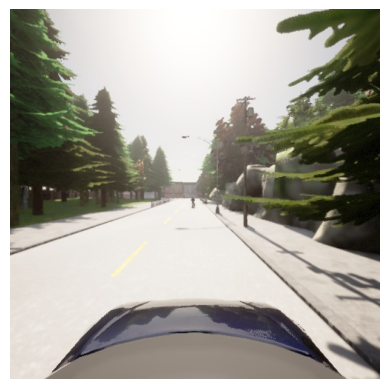

In [41]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('train/rgb-front/000000.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

In [42]:
train_labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [49]:
sample_rows = train_labels.sample(5)
sample_rows.head()


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
3820,38200,False,False,True,23,0,187
1764,17640,False,False,False,0,0,0
6328,63280,True,False,True,68,0,126
6745,67450,True,False,True,170,0,15188
4902,49020,True,False,True,407,5,98


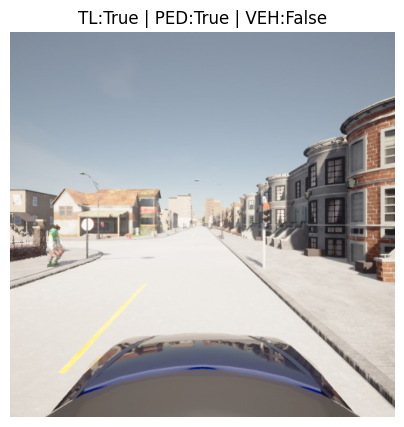

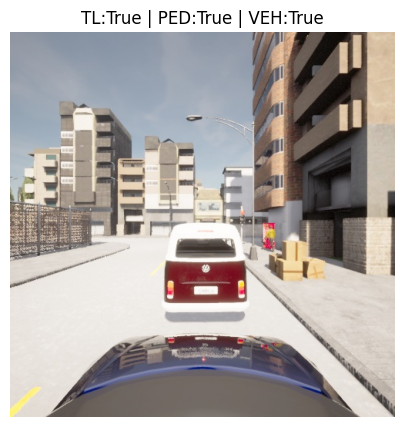

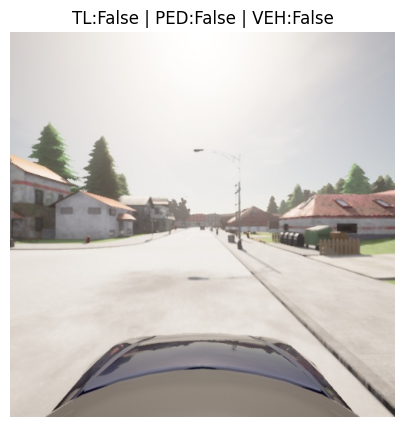

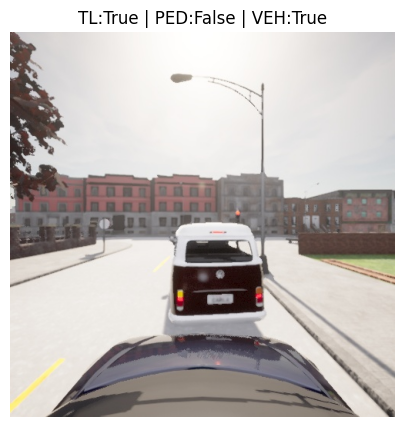

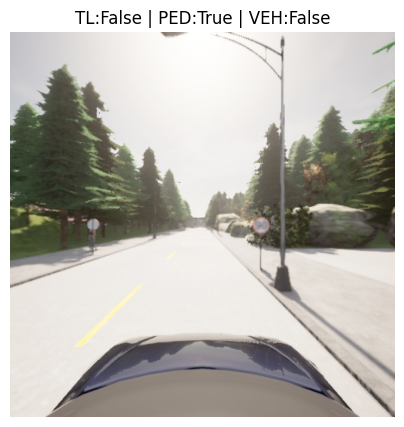

In [48]:
for _, row in sample_rows.iterrows():

    frame = str(row['frame']).zfill(6)
    
    img = Image.open(f'train/rgb-front/{frame}.jpg')

    plt.figure(figsize=(5,5))
    plt.imshow(img)

    title = f"TL:{row['has_traffic_light']} | PED:{row['has_pedestrian']} | VEH:{row['has_vehicle']}"
    
    plt.title(title)

    plt.axis('off')
    plt.show()

# Exercise 3.5: Train Three Binary Classifiers


In [1]:
!pip install torch torchvision

In [2]:
import torch
import torchvision

print(torch.__version__)

2.12.0


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt

PyTorch Dataset

This class:

loads images
loads labels
converts image → tensor
returns:

In [4]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):

        self.labels = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])


        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(label)

define image transformations.
Neural networks cannot directly use raw images.
We must:

resize them
convert to tensors
normalize them

Why 224×224?
Because ResNet18 expects that size.

In [5]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# train the vehicle classifier

create datasets

In [9]:
train_dataset = CarlaDataset(

    csv_file='train/labels.csv',

    img_dir='train/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='validation/labels.csv',

    img_dir='validation/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

create dataloaders

This prepares batches for training.

In [10]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

load ResNet18 and load already trained on ImageNet

In [11]:
model = models.resnet18(pretrained=True)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/maverick/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 18.6MB/s]


Now replace final layer:
because, Original ResNet predicts 1000 classes.

In [12]:
model.fc = nn.Linear(model.fc.in_features, 1)

Binary Cross Entropy loss
Adam optimizer
learning rate = 0.001

In [13]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

for mac m1 pro, we can use Apple Silicon acceleration.

In [14]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(device)

mps


Now move model to device:

In [15]:
model = model.to(device)

## actual training

In [16]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.3282
Validation Loss: 0.4849
Epoch 2/5
Train Loss: 0.2318
Validation Loss: 0.7053
Epoch 3/5
Train Loss: 0.2027
Validation Loss: 0.2924
Epoch 4/5
Train Loss: 0.1746
Validation Loss: 0.2930
Epoch 5/5
Train Loss: 0.1572
Validation Loss: 0.2734


Epoch 1/5
Train Loss: 0.3282
Validation Loss: 0.4849

Epoch 2/5
Train Loss: 0.2318
Validation Loss: 0.7053

Epoch 3/5
Train Loss: 0.2027
Validation Loss: 0.2924

1. Training loss continuously decreases:
2. model is learning patterns.
3. Validation loss also generally decreases.
4. spike in epoch 2 is normal sometimes due to:
batch variation, optimizer updates, early instability

Now we plot plot the losses.

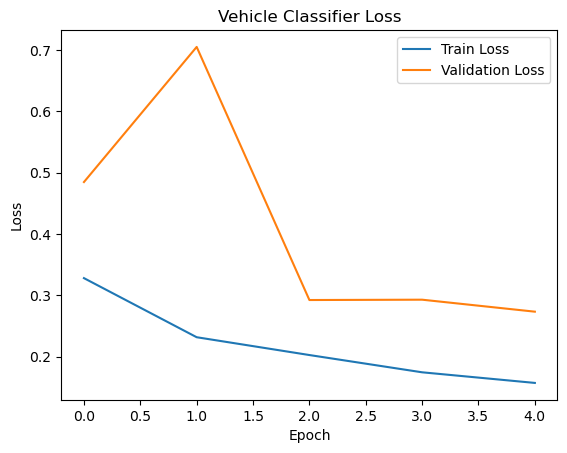

In [17]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Vehicle Classifier Loss')

plt.legend()

plt.show()

# 2. train the Pedestrian classifier

In [25]:
train_dataset = CarlaDataset(

    csv_file='train/labels.csv',

    img_dir='train/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='validation/labels.csv',

    img_dir='validation/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

In [26]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

### reinitialize model again:

In [27]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

In [29]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.5183
Validation Loss: 0.9475
Epoch 2/5
Train Loss: 0.4369
Validation Loss: 0.5785
Epoch 3/5
Train Loss: 0.3768
Validation Loss: 0.7156
Epoch 4/5
Train Loss: 0.3249
Validation Loss: 0.5771
Epoch 5/5
Train Loss: 0.3005
Validation Loss: 0.6950


### plot

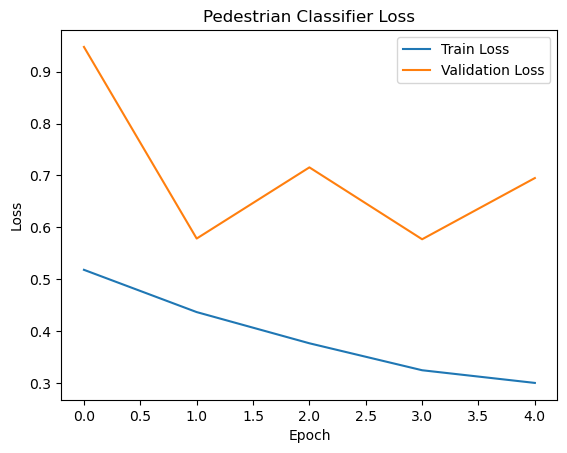

In [30]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Pedestrian Classifier Loss')

plt.legend()

plt.show()

# 3. train the Traffic Light classifier

In [33]:
train_dataset = CarlaDataset(

    csv_file='train/labels.csv',

    img_dir='train/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='validation/labels.csv',

    img_dir='validation/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

In [34]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

### reinitialize model again:

In [38]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

In [39]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

In [40]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.1851
Validation Loss: 0.1046
Epoch 2/5
Train Loss: 0.0872
Validation Loss: 0.1348
Epoch 3/5
Train Loss: 0.0674
Validation Loss: 0.1159
Epoch 4/5
Train Loss: 0.0490
Validation Loss: 0.1063
Epoch 5/5
Train Loss: 0.0474
Validation Loss: 0.0689


### plot

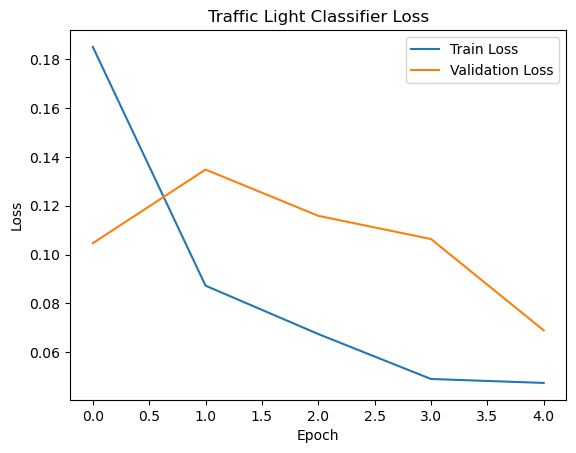

In [41]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Traffic Light Classifier Loss')

plt.legend()

plt.show()

# Exercise 3.6: Evaluation

install sklearn

In [42]:
!pip install scikit-learn

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

create test dataset [vehicle classifier]

In [44]:
test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

evaluation code

This collects:
predictions
true labels

In [45]:
model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

metrics

In [46]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds)

recall = recall_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-score:", f1)

Accuracy: 0.6677777777777778
Precision: 0.7801788375558867
Recall: 0.7755555555555556
F1-score: 0.7778603268945022


Save model

In [47]:
torch.save(model.state_dict(), 'vehicle_model.pth')
